# ML Final Project — Mice Protein Expression (UCI)

Group members:
- Rami Abou Fakhr (ID: 2185019)
- Amir H. Q. Selakjan (ID: 2183917)
- Alison Mae Worth (ID: 2183914)

Group: 8
Dataset: Mice Protein Expression — UCI (ID 342)
Task: Binary classification — control vs trisomic genotype

---

## Section 0 — Setup

In [20]:
# Section 0 - Setup

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    fetch_ucirepo = None
    print("ucimlrepo not installed. Run: pip install ucimlrepo")

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

In [21]:
# If ucimlrepo isn't installed in this kernel yet, install it then import.
# %pip installs into the exact Python this notebook is running on.
%pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

Note: you may need to restart the kernel to use updated packages.


---

## Section 1 — Biological question

### Background

Down syndrome is caused by trisomy of chromosome 21, however the molecular mechanisms involved downstream are not fully understood.  To study the molecular basis and effect of a disease, many scientists utilize in vivo mouse models.   The Ts65Dn model, which carries a partial trisomy of mouse chromosome 16, is one of the most widely used mouse models for studying down syndrome.

This dataset was collected by Higuera et al. (2015) and contains protein expression levels measured in the cerebral cortex of control and trisomic mice that were either stimulated to learn (via context fear conditioning) or left unstimulated, and treated with memantine or saline.

### Biological question

> Can we classify mice as control or trisomic based solely on their cortical protein expression profile?

### Structured answer

```
Biological question:
    Can we predict whether a mouse has a trisomic (Ts65Dn) or control genotype
    from the expression levels of 77 proteins measured in the cerebral cortex?

Input data:
    Protein expression levels (77 proteins) measured from mouse cortex tissue.
    Each value is a normalized fluorescence intensity from antibody-based
    protein quantification.

Target variable:
    Genotype — binary: "Control" (normal diploid) vs "Ts65Dn" (trisomic).

One row represents:
    A single mouse cortex sample (one measurement session per mouse).

One column represents:
    The normalized expression level of one specific protein across all mice.

Biological relevance:
    Identifying which proteins differ between genotypes can reveal molecular
    pathways disrupted in trisomy 21. This is relevant both for understanding
    Down syndrome mechanisms and for identifying potential therapeutic targets.
    A classifier that separates genotypes purely from protein levels confirms
    that the proteomic signature of trisomy is detectable at the individual
    sample level, not only at the group mean level.
```

---

## Section 2 — Load the dataset

In [22]:
# Section 2 - Load the dataset

if fetch_ucirepo is None:
    raise ImportError("ucimlrepo is required. Install with: pip install ucimlrepo")

mice = fetch_ucirepo(id=342)

mice_features = mice.data.features.copy()
mice_targets  = mice.data.targets.copy()
mice_original = mice.data.original.copy()

print("Feature columns (first 10):", mice_features.columns.tolist()[:10], "...")
print("Target columns:",             mice_targets.columns.tolist())
print("Original columns (first 15):",mice_original.columns.tolist()[:15], "...")
print()
print("Dataset shape (features):", mice_features.shape)

mice_original.head()

Feature columns (first 10): ['DYRK1A_N', 'ITSN1_N', 'BDNF_N', 'NR1_N', 'NR2A_N', 'pAKT_N', 'pBRAF_N', 'pCAMKII_N', 'pCREB_N', 'pELK_N'] ...
Target columns: ['class']
Original columns (first 15): ['MouseID', 'DYRK1A_N', 'ITSN1_N', 'BDNF_N', 'NR1_N', 'NR2A_N', 'pAKT_N', 'pBRAF_N', 'pCAMKII_N', 'pCREB_N', 'pELK_N', 'pERK_N', 'pJNK_N', 'PKCA_N', 'pMEK_N'] ...

Dataset shape (features): (1080, 80)


,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


### Reflection points for Section 2

In [23]:
# Point 2.1 - Number of samples and variables
n_samples, n_vars = mice_features.shape
print(f"Number of samples:   {n_samples}")
print(f"Number of variables: {n_vars}")

Number of samples:   1080
Number of variables: 80


Point 2.1 — Number of samples and variables: The dataset has 1,080 samples. `mice.data.features` returns 80 columns: 77 numeric protein expression features plus three categorical metadata columns (`Genotype`, `Treatment`, `Behavior`). The 77 protein features are the actual model inputs and are isolated in Section 4 with `select_dtypes(include="number")`.

In [24]:
# Point 2.2 - Column roles
print("=== Columns in mice_original but NOT in mice.data.features ===")
metadata_cols = [c for c in mice_original.columns if c not in mice_features.columns]
print(metadata_cols)
print()
print("=== Columns inside mice.data.features ===")
print(mice_features.columns.tolist())
print()
print("=== Target (Genotype, taken from mice_original) ===")
print(mice_original["Genotype"].value_counts())

=== Columns in mice_original but NOT in mice.data.features ===
['MouseID', 'class']

=== Columns inside mice.data.features ===
['DYRK1A_N', 'ITSN1_N', 'BDNF_N', 'NR1_N', 'NR2A_N', 'pAKT_N', 'pBRAF_N', 'pCAMKII_N', 'pCREB_N', 'pELK_N', 'pERK_N', 'pJNK_N', 'PKCA_N', 'pMEK_N', 'pNR1_N', 'pNR2A_N', 'pNR2B_N', 'pPKCAB_N', 'pRSK_N', 'AKT_N', 'BRAF_N', 'CAMKII_N', 'CREB_N', 'ELK_N', 'ERK_N', 'GSK3B_N', 'JNK_N', 'MEK_N', 'TRKA_N', 'RSK_N', 'APP_N', 'Bcatenin_N', 'SOD1_N', 'MTOR_N', 'P38_N', 'pMTOR_N', 'DSCR1_N', 'AMPKA_N', 'NR2B_N', 'pNUMB_N', 'RAPTOR_N', 'TIAM1_N', 'pP70S6_N', 'NUMB_N', 'P70S6_N', 'pGSK3B_N', 'pPKCG_N', 'CDK5_N', 'S6_N', 'ADARB1_N', 'AcetylH3K9_N', 'RRP1_N', 'BAX_N', 'ARC_N', 'ERBB4_N', 'nNOS_N', 'Tau_N', 'GFAP_N', 'GluR3_N', 'GluR4_N', 'IL1B_N', 'P3525_N', 'pCASP9_N', 'PSD95_N', 'SNCA_N', 'Ubiquitin_N', 'pGSK3B_Tyr216_N', 'SHH_N', 'BAD_N', 'BCL2_N', 'pS6_N', 'pCFOS_N', 'SYP_N', 'H3AcK18_N', 'EGR1_N', 'H3MeK4_N', 'CaNA_N', 'Genotype', 'Treatment', 'Behavior']

=== Target (Gen

Point 2.2 — Column roles:
- Columns in `mice_original` but not in `mice.data.features`: only `MouseID` and `class`.
- Input features: 77 columns of normalized protein expression levels (numeric `float64`). Note that `mice.data.features` also bundles three categorical columns — `Genotype`, `Treatment`, `Behavior` — which describe experimental conditions, not protein measurements.
- Target: The repository's designated target (`mice.data.targets`) is `class`, an 8-category label. For this binary project the target is `Genotype` — two values, `Control` and `Ts65Dn` — taken from `mice_original`.

In [25]:
# Point 2.3 - Missing values
missing_per_col = mice_features.isnull().sum()
print("Columns with missing values:")
print(missing_per_col[missing_per_col > 0].sort_values(ascending=False).head(10))
print()
total_missing = missing_per_col.sum()
total_cells   = mice_features.shape[0] * mice_features.shape[1]
print(f"Total missing cells: {total_missing} / {total_cells} ({100*total_missing/total_cells:.2f}%)")

Columns with missing values:
BCL2_N        285
H3MeK4_N      270
BAD_N         213
EGR1_N        210
H3AcK18_N     180
pCFOS_N        75
ELK_N          18
Bcatenin_N     18
MEK_N           7
ITSN1_N         3
dtype: int64

Total missing cells: 1396 / 86400 (1.62%)


Point 2.3 — Missing values: Missing values affect 49 of the feature columns, totalling about 1.6% of all feature cells. No column is completely empty, but the missingness is uneven — most columns lose only a few values, while the most affected (`BCL2_N`) is missing about 26% of its entries. The plan is to impute with the column median (not mean), because protein expression data can be skewed by outliers and median imputation is more robust in that case. This is done in Section 6 (preprocessing) after the train/test split to avoid data leakage.

In [26]:
# Point 2.4 - Data types
print("Data types in the features object:")
print(mice_features.dtypes.value_counts())
print()
print("Non-numeric columns (if any):")
non_numeric = mice_features.select_dtypes(exclude="number").columns.tolist()
print(non_numeric if non_numeric else "None")

Data types in the features object:
float64    77
object      3
Name: count, dtype: int64

Non-numeric columns (if any):
['Genotype', 'Treatment', 'Behavior']


Point 2.4 — Data types: `mice.data.features` contains 77 numeric (`float64`) protein columns and 3 object (text) columns — `Genotype`, `Treatment`, `Behavior`. So `select_dtypes(exclude="number")` returns those three categorical columns, not `None`. They are experimental-condition labels rather than measurements; Section 4 keeps only the 77 numeric protein columns as `X`. No unexpected types are present among the protein features.

---

## Section 3 — Identify the ML task

In [27]:
# Section 3 - Identify the ML task

print("Target variable: Genotype")
print("Unique values:", mice_original["Genotype"].unique())
print("Value counts:")
print(mice_original["Genotype"].value_counts())
print()
print("Number of unique classes:", mice_original["Genotype"].nunique())
print("Target dtype:", mice_original["Genotype"].dtype)

Target variable: Genotype
Unique values: ['Control' 'Ts65Dn']
Value counts:
Genotype
Control    570
Ts65Dn     510
Name: count, dtype: int64

Number of unique classes: 2
Target dtype: object


```
Target type:       Categorical, binary (two classes)

Problem type:      Binary classification
                   The target is "Control" vs "Ts65Dn" — two discrete categories.
                   There is no natural ordering, so regression is not appropriate.

Compatible models: Logistic Regression, Decision Tree, Random Forest,
                   K-Nearest Neighbours, Support Vector Classifier, Neural Network

Models that are not appropriate and why:
  - Linear Regression: the target is categorical, not continuous.
    Predicting a real number makes no biological sense here.
  - Regression trees (for continuous targets): same reason.
  - Unsupervised methods (PCA, k-means): we have labels, so supervised
    classification is the right framework.
```

---

## Section 4 — Define X and y

In [28]:
# Section 4 - Define X and y

# X = the protein columns (only the numeric ones)
X = mice_features.select_dtypes(include="number").copy()

# y = genotype turned into numbers with LabelEncoder (Control=0, Ts65Dn=1)
le = LabelEncoder()
y = pd.Series(le.fit_transform(mice_original["Genotype"]), name="Genotype_encoded")

print("Encoder classes:", le.classes_)   # order matches 0, 1
print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Counts in y:")
print(y.value_counts())

Encoder classes: ['Control' 'Ts65Dn']
X shape: (1080, 77)
y shape: (1080,)

Counts in y:
Genotype_encoded
0    570
1    510
Name: count, dtype: int64


### Reflection points for Section 4

Point 4.1 — Shape of X:
`X` has shape (1080, 77).
- Dimension 0 (rows = 1080): each row is one mouse cortex sample.
- Dimension 1 (columns = 77): each column is the normalized expression level of one protein.

Point 4.2 — Shape of y:
`y` has shape (1080,). Each element is a binary label: `0` for control mice, `1` for trisomic (Ts65Dn) mice.

Point 4.3 — Transpose:
No transposition was needed. The UCI repository already provides `mice.data.features` in ML-standard orientation (rows = samples, columns = proteins). This is different from some gene expression formats (e.g., GEO matrices) where genes are rows and samples are columns and a transpose is required.

Point 4.4 — Alternative ML tasks from the same dataset:
The dataset contains additional columns that could be used as alternative targets:
- `Treatment` (memantine vs saline) → different binary classification question
- `Behavior` (context-shock vs shock-only stimulation) → another binary classification
- `class` → an 8-class multiclass problem (combinations of genotype × treatment × behavior)

The choice of target changes the biological question entirely. Using `class` instead of `Genotype` would ask whether we can distinguish all experimental conditions at once, which is harder and less interpretable. I chose `Genotype` because it is the most direct proxy for the Down syndrome model phenotype.

---

## Section 5 — Dataset audit

In [29]:
# Section 5 - Dataset audit

# 5a: size relative to features
print("=== Size and dimensionality ===")
print(f"Samples:  {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Ratio samples/features: {X.shape[0] / X.shape[1]:.1f}")

=== Size and dimensionality ===
Samples:  1080
Features: 77
Ratio samples/features: 14.0


=== Class balance ===
Genotype_encoded
0    570
1    510
Name: count, dtype: int64

Class 0 (Control):  570 samples (52.8%)
Class 1 (Ts65Dn):   510 samples (47.2%)


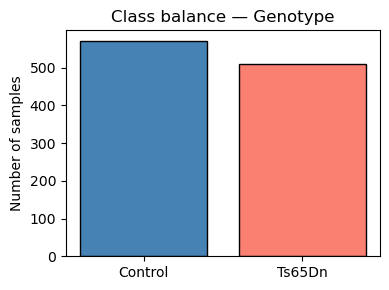

In [30]:
# 5b: class balance
print("=== Class balance ===")
counts = y.value_counts()
print(counts)
print()
print(f"Class 0 (Control):  {counts[0]} samples ({100*counts[0]/len(y):.1f}%)")
print(f"Class 1 (Ts65Dn):   {counts[1]} samples ({100*counts[1]/len(y):.1f}%)")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["Control", "Ts65Dn"], [counts[0], counts[1]], color=["steelblue", "salmon"], edgecolor="black")
ax.set_ylabel("Number of samples")
ax.set_title("Class balance — Genotype")
plt.tight_layout()
plt.show()

In [31]:
# 5c: missing values summary
print("=== Missing values ===")
missing_col = X.isnull().sum()
print(f"Columns with at least one missing value: {(missing_col > 0).sum()} / {X.shape[1]}")
print()
print("Top columns by missingness:")
print(missing_col[missing_col > 0].sort_values(ascending=False).head(10))

=== Missing values ===
Columns with at least one missing value: 49 / 77

Top columns by missingness:
BCL2_N        285
H3MeK4_N      270
BAD_N         213
EGR1_N        210
H3AcK18_N     180
pCFOS_N        75
ELK_N          18
Bcatenin_N     18
MEK_N           7
ITSN1_N         3
dtype: int64


In [32]:
# 5d: check the value ranges of the features
print("=== Feature value ranges ===")
print("Smallest value overall:", round(X.min().min(), 4))
print("Biggest value overall: ", round(X.max().max(), 4))
print("Average of column means:", round(X.mean().mean(), 4))
print("Smallest column std:", round(X.std().min(), 4))
print("Biggest column std: ", round(X.std().max(), 4))

=== Feature value ranges ===
Smallest value overall: -0.062
Biggest value overall:  8.4826
Average of column means: 0.6719
Smallest column std: 0.0132
Biggest column std:  1.2952


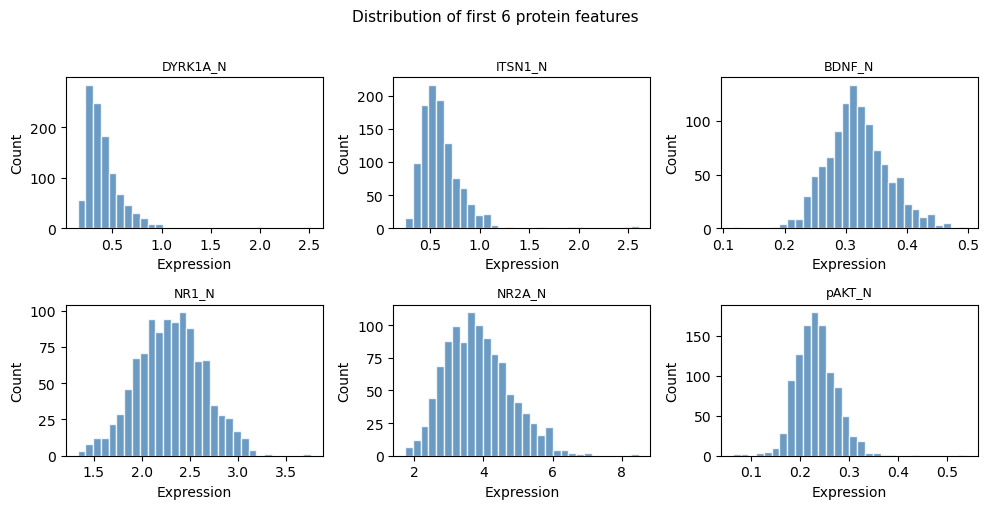

In [33]:
# 5e: distribution of a few proteins to check for outliers / skew
sample_proteins = X.columns[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
axes = axes.flatten()

for i, col in enumerate(sample_proteins):
    axes[i].hist(X[col].dropna(), bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("Expression")
    axes[i].set_ylabel("Count")

plt.suptitle("Distribution of first 6 protein features", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

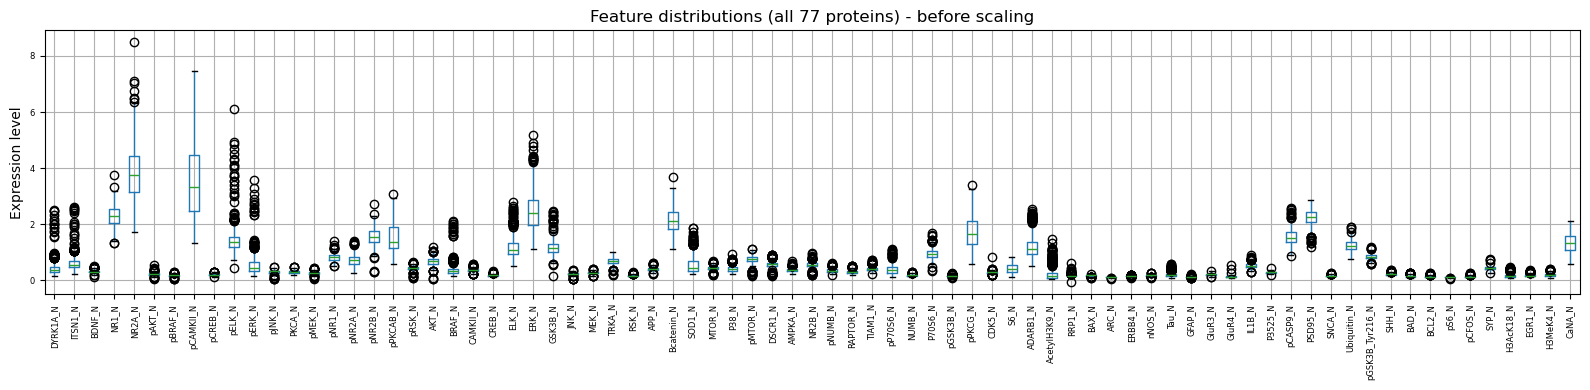

In [34]:
# 5f: boxplot of all the proteins to see the different scales
plt.figure(figsize=(16, 4))
X.boxplot(rot=90, fontsize=6)
plt.title("Feature distributions (all 77 proteins) - before scaling")
plt.ylabel("Expression level")
plt.tight_layout()
plt.show()

### Reflection points for Section 5

Point 5.1 — Dataset size relative to features:
1,080 samples with 77 features gives a ratio of ~14:1. This is a reasonable medium-sized dataset. It is large enough for ensemble methods like Random Forest, and small enough that a large neural network could overfit easily. Logistic regression is also appropriate at this scale.

Point 5.2 — Class balance:
The dataset is close to even but mildly imbalanced: 570 Control (52.8%) and 510 Ts65Dn (47.2%). Accuracy is still a reasonable metric, but the relevant no-information baseline is a majority-class classifier scoring ~52.8%, not 50%. The imbalance is small enough that no resampling or class-weight adjustment is required; stratified splitting preserves the ratio across folds.

Point 5.3 — Feature scaling:
The protein expression values are normalized intensities that mostly sit below ~1 (the average feature mean is ~0.67), but individual values range from slightly below 0 (about -0.06) up to ~8.5, and the per-feature standard deviations vary widely (~0.01 to ~1.3). Because the scales and spreads differ across proteins, `StandardScaler` should be applied for:
- Logistic Regression (gradient-descent-based, sensitive to scale)
- KNN (distance-based, very sensitive to scale)

Random Forest and Decision Tree are scale-invariant (split on individual feature values), so scaling is not required for those — but it does not hurt to apply it uniformly for consistency.

Point 5.4 — Main risks:
- Data leakage: The features object includes the categorical columns `Genotype`, `Treatment`, and `Behavior`, which are correlated with the target by experimental design. If any of these leaked into X, the classifier would be partially predicting the experimental condition rather than learning the proteomic signature. This is avoided by selecting only the numeric protein columns as X.
- Mild multicollinearity: Some proteins in the same signaling pathway are likely correlated. This can inflate variance in logistic regression coefficients but does not prevent classification.
- Sparse missing values: handled by imputation (not deletion).

---

## Section 6 — Pre-processing and Baseline Modeling

In [35]:
# Section 6 - Pre-processing
# Split first, then impute and scale using only the training data (no leakage)

# first split off the test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# then split the rest into train and validation
# 0.25 of the 80% = 20% of everything, so it ends up 60/20/20
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full)

print("Train size:", X_train.shape[0])
print("Val size:  ", X_val.shape[0])
print("Test size: ", X_test.shape[0])
print()

# check the class balance is about the same in each split
for name, ysplit in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    n0 = (ysplit == 0).sum()
    n1 = (ysplit == 1).sum()
    print(name, "-> Control:", n0, " Ts65Dn:", n1)

Train size: 648
Val size:   216
Test size:  216

Train -> Control: 342  Ts65Dn: 306
Val -> Control: 114  Ts65Dn: 102
Test -> Control: 114  Ts65Dn: 102


In [36]:
# fill in missing values with the median of each column (fit on train only)
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

# scale the features to mean 0 / std 1 (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_val_sc   = scaler.transform(X_val_imp)
X_test_sc  = scaler.transform(X_test_imp)

print("Shapes after imputing and scaling:")
print("X_train:", X_train_sc.shape)
print("X_val:  ", X_val_sc.shape)
print("X_test: ", X_test_sc.shape)
print()
print("Train mean (should be about 0):", round(X_train_sc.mean(), 3))
print("Train std (should be about 1): ", round(X_train_sc.std(), 3))

Shapes after imputing and scaling:
X_train: (648, 77)
X_val:   (216, 77)
X_test:  (216, 77)

Train mean (should be about 0): 0.0
Train std (should be about 1):  1.0


Pre-processing rationale:
- Imputer fitted on train only. The validation and test medians are not known at training time, so they must be estimated from training data only. Using the full dataset's median would leak information about the test set into the imputation.
- Scaler fitted on train only. Same reason — the scaler's mean and standard deviation come only from the training samples.
- Stratified splits. Because the dataset is only mildly imbalanced (about 53/47), stratified splitting keeps that same class ratio in each split.

### Baseline model (Dummy classifier)

In [37]:
# Baseline: DummyClassifier (most_frequent)

# little helper so I don't have to retype the metrics for every model
def show_scores(y_true, y_pred):
    print("Accuracy: ", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall:   ", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1 score: ", round(f1_score(y_true, y_pred, zero_division=0), 4))

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_sc, y_train)
y_val_dummy = dummy.predict(X_val_sc)

print("=== Baseline: DummyClassifier (most frequent class) ===")
show_scores(y_val, y_val_dummy)
print()
print("The baseline always predicts the majority class (Control).")
print("Any useful model needs to score clearly above this.")

=== Baseline: DummyClassifier (most frequent class) ===
Accuracy:  0.5278
Precision: 0.0
Recall:    0.0
F1 score:  0.0

The baseline always predicts the majority class (Control).
Any useful model needs to score clearly above this.


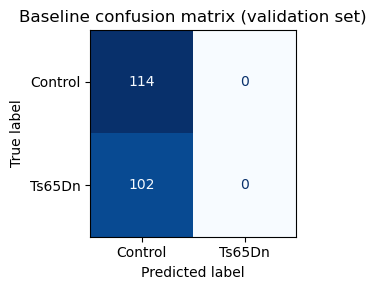

In [38]:
# Confusion matrix for baseline
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_dummy,
    display_labels=["Control", "Ts65Dn"],
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Baseline confusion matrix (validation set)")
plt.tight_layout()
plt.show()

### Reflection points for Section 6 (Baseline)

Point 6.1 — Choice of baseline:
The `DummyClassifier` with `strategy='most_frequent'` was chosen. It always predicts the majority class (Control), which achieves about 52.8% accuracy on this slightly imbalanced dataset.

Point 6.2 — Why this baseline is appropriate:
The most-frequent baseline formalizes the "no-information" performance level — the score obtained by ignoring the protein data entirely and always guessing the larger class. Any model that genuinely learns from protein expression must score well above this ~52.8%.

Point 6.3 — Baseline performance on validation:
As expected, accuracy is ~53%. Because the classifier only ever predicts the majority class, precision, recall, and F1 for the minority class are zero (or undefined) — `zero_division=0` handles this gracefully.

Point 6.4 — Threshold for a useful model:
A useful model must exceed the ~52.8% majority-class rate by a meaningful margin (say, >65-70% accuracy) on the validation set before it is worth interpreting biologically. Given that genotype differences in protein expression are well-documented in the literature (Higuera et al. 2015 reported very clear separation), we expect candidate models to achieve considerably higher accuracy than the baseline.

---

## Section 7 — Candidate models and justification

```
Baseline model:
    DummyClassifier (majority class predictor)
    Expected accuracy: ~52.8% (always predicts the majority class, Control)

Candidate model 1: Logistic Regression
Why this model:
    Standard first choice for binary classification. Interpretable
    coefficients allow identifying which proteins drive the decision.
    Works well when the class boundary is approximately linear in feature
    space, which is plausible here because protein expression differences
    between genotypes may be additive.
Expected advantage:
    Interpretable, fast, well-regularized with L2 penalty (Ridge).
    Coefficients can be mapped back to biological protein names.
Expected risk:
    With 77 features and ~640 training samples the model may
    underfit if the relationship is nonlinear, or overfit if
    many correlated proteins are included. Regularization (C parameter)
    must be tuned.

Candidate model 2: Random Forest Classifier
Why this model:
    Handles nonlinear interactions and feature correlations well.
    Provides feature importances that are biologically interpretable.
    Does not require feature scaling. Robust to a small number of
    irrelevant features.
Expected advantage:
    Higher accuracy than logistic regression if the genotype boundary
    is nonlinear in protein space. Less sensitive to multicollinearity.
Expected risk:
    Black-box relative to logistic regression. Feature importances
    from Random Forest can be biased toward high-cardinality features
    (less relevant here since all features are continuous).
    May overfit on a small training set if trees are too deep.

Candidate model 3 (optional): K-Nearest Neighbours
Why this model:
    Nonparametric, makes no assumptions about the form of the decision
    boundary. Useful as a comparison point to check whether the
    classification problem has a local geometric structure.
Expected advantage:
    Simple, no training phase. Good for checking if nearby samples
    in protein space share genotype.
Expected risk:
    Suffers in higher dimensions (77 features is moderately high).
    Very sensitive to scaling and to irrelevant features. Slow at
    inference on large datasets.
```

### Reflection points for Section 7

Point 7.1 — Feature scaling requirements:

| Model | Scaling required? | Reason |
|---|---|---|
| Logistic Regression | Yes | Uses gradient-based optimisation; features on different scales cause uneven updates and slow convergence |
| Random Forest | No | Splits on individual feature thresholds; scale does not affect split quality |
| KNN | Yes | Uses Euclidean distance; large-scale features dominate distance calculations |

Since all three models will be compared, I apply `StandardScaler` uniformly to all.

Point 7.2 — Key hyperparameters per model:

| Model | Key hyperparameter | Effect |
|---|---|---|
| Logistic Regression | `C` (inverse of regularisation strength) | Low C = strong regularisation = underfitting risk; High C = weak regularisation = overfitting risk |
| Random Forest | `n_estimators`, `max_depth` | More trees = lower variance; deeper trees = higher variance |
| KNN | `n_neighbors` (k) | Small k = complex boundary; large k = smoother boundary |

Point 7.3 — Ranking from most to least interpretable:
1. Logistic Regression — signed coefficients per feature, directly shows which proteins push toward one class
2. Decision Tree (if used) — explicit split rules
3. Random Forest — feature importances available, but the ensemble as a whole is not directly readable
4. KNN — no parameters to inspect; the "model" is just the training data

Point 7.4 — Most likely to overfit:
KNN with small k is the most prone to overfitting, because it will memorize local training noise. Random Forest with very deep trees can also overfit, but the ensemble averaging mitigates this. Logistic Regression with strong regularisation (small C) is the least likely to overfit.